In [1]:
import sys
print(sys.executable)

e:\Predictive-vehicle-maintenance-with-road-analysis\Model\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better looking plots
plt.style.use('ggplot')

In [3]:
df = pd.read_csv("data/raw/logistics_predictive_maintenanceV2.csv")
df.head()
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 250000
Columns : 50


In [4]:
df.columns

Index(['Vehicle_ID', 'Make_and_Model', 'Vehicle_Type', 'Year_of_Manufacture',
       'Route_Info', 'Weather_Conditions', 'Road_Conditions',
       'Communication_Interface', 'Telematics_Gateway', 'Edge_Device_Class',
       'Usage_Hours', 'Load_Capacity', 'Actual_Load', 'Engine_Temperature',
       'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status',
       'Vibration_Levels', 'Oil_Quality', 'Failure_History',
       'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',
       'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 'Maintenance_Cost',
       'Historical_Maintenance_Cost', 'Downtime_Maintenance',
       'Impact_on_Efficiency', 'Days_Since_Last_Maintenance',
       'Last_Maintenance_Date', 'Maintenance_Type', 'Brake_Condition',
       'Maintenance_Severity', 'Maintenance_Severity_ID',
       'Maintenance_Required', 'PCR', 'UIR', 'TPI', 'MBF', 'ADS', 'OHI',
       'CMES', 'UER', 'Predictive_Score', 'Pre_Event_Record', 'Data_Split',
       'FL_Client_ID', 'Partition_Type', 'L

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Vehicle_ID                     250000 non-null  int64  
 1   Make_and_Model                 250000 non-null  str    
 2   Vehicle_Type                   250000 non-null  str    
 3   Year_of_Manufacture            250000 non-null  float64
 4   Route_Info                     250000 non-null  str    
 5   Weather_Conditions             250000 non-null  str    
 6   Road_Conditions                250000 non-null  str    
 7   Communication_Interface        250000 non-null  str    
 8   Telematics_Gateway             250000 non-null  str    
 9   Edge_Device_Class              250000 non-null  str    
 10  Usage_Hours                    250000 non-null  float64
 11  Load_Capacity                  250000 non-null  float64
 12  Actual_Load                    250000 non

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle_ID,250000.0,125000.500000,72168.927986,1.000000,62500.750000,125000.500000,187500.250000,250000.000000
Year_of_Manufacture,250000.0,2017.001648,4.404508,2006.208751,2013.253246,2016.992874,2020.751893,2027.960511
Usage_Hours,250000.0,11606.034549,6405.424404,0.000000,6172.454381,11597.787625,17040.600677,26923.050540
Load_Capacity,250000.0,10204.023036,7506.528226,0.000000,3701.744177,9035.358668,15662.385282,31002.920260
Actual_Load,250000.0,6365.064059,5125.420435,0.000000,2226.606363,5079.285254,9483.329825,29565.774450
Engine_Temperature,250000.0,93.209653,10.657330,57.620164,85.644726,91.280880,99.161245,134.866138
Tire_Pressure,250000.0,33.396828,3.594448,15.731657,31.426667,33.939064,35.891026,45.766611
Fuel_Consumption,250000.0,9.597667,3.105208,2.210886,7.455581,8.760228,11.040259,23.662851
Battery_Status,250000.0,76.478950,14.334168,17.889281,68.185679,79.929082,86.805010,110.003448
Vibration_Levels,250000.0,2.045674,1.680241,0.000000,0.972980,1.511896,2.498355,10.553589


In [7]:
df.describe(include="object").T

C:\Users\ragav\AppData\Local\Temp\ipykernel_7536\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Make_and_Model,250000,8,Volvo FH,31390
Vehicle_Type,250000,5,Heavy Truck,50294
Route_Info,250000,5,Port-to-Warehouse,50156
Weather_Conditions,250000,6,Foggy,41930
Road_Conditions,250000,5,Mountainous,50397
Communication_Interface,250000,4,OBD-II/CAN,137770
Telematics_Gateway,250000,4,Fleet_IoT_Node,62605
Edge_Device_Class,250000,4,ARM_Cortex_A72,62799
Last_Maintenance_Date,250000,701,26-10-2024,1244
Maintenance_Type,250000,11,Oil Check,58377


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [10]:
df["Maintenance_Required"].value_counts()

Maintenance_Required
0    163126
1     86874
Name: count, dtype: int64

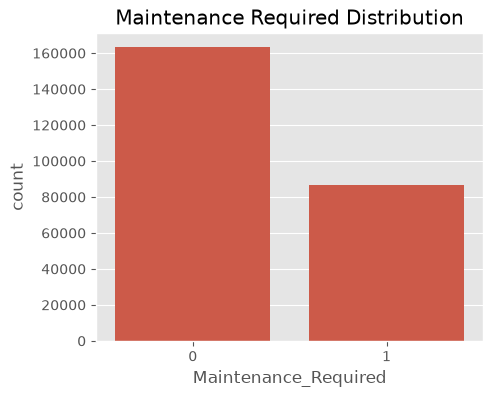

In [11]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="Maintenance_Required",
    data=df
)

plt.title("Maintenance Required Distribution")
plt.show()

In [12]:
numerical_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

print(numerical_columns)

Index(['Vehicle_ID', 'Year_of_Manufacture', 'Usage_Hours', 'Load_Capacity',
       'Actual_Load', 'Engine_Temperature', 'Tire_Pressure',
       'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality',
       'Failure_History', 'Anomalies_Detected',
       'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz',
       'Sensor_Packet_Loss_Rate', 'Maintenance_Cost',
       'Historical_Maintenance_Cost', 'Downtime_Maintenance',
       'Impact_on_Efficiency', 'Days_Since_Last_Maintenance',
       'Maintenance_Severity_ID', 'Maintenance_Required', 'PCR', 'UIR', 'TPI',
       'MBF', 'ADS', 'OHI', 'CMES', 'UER', 'Predictive_Score',
       'Pre_Event_Record', 'FL_Client_ID', 'Local_Epochs_Per_Round',
       'Communication_Rounds'],
      dtype='str')


In [13]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['Make_and_Model', 'Vehicle_Type', 'Route_Info', 'Weather_Conditions',
       'Road_Conditions', 'Communication_Interface', 'Telematics_Gateway',
       'Edge_Device_Class', 'Last_Maintenance_Date', 'Maintenance_Type',
       'Brake_Condition', 'Maintenance_Severity', 'Data_Split',
       'Partition_Type'],
      dtype='str')


C:\Users\ragav\AppData\Local\Temp\ipykernel_7536\3603927628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


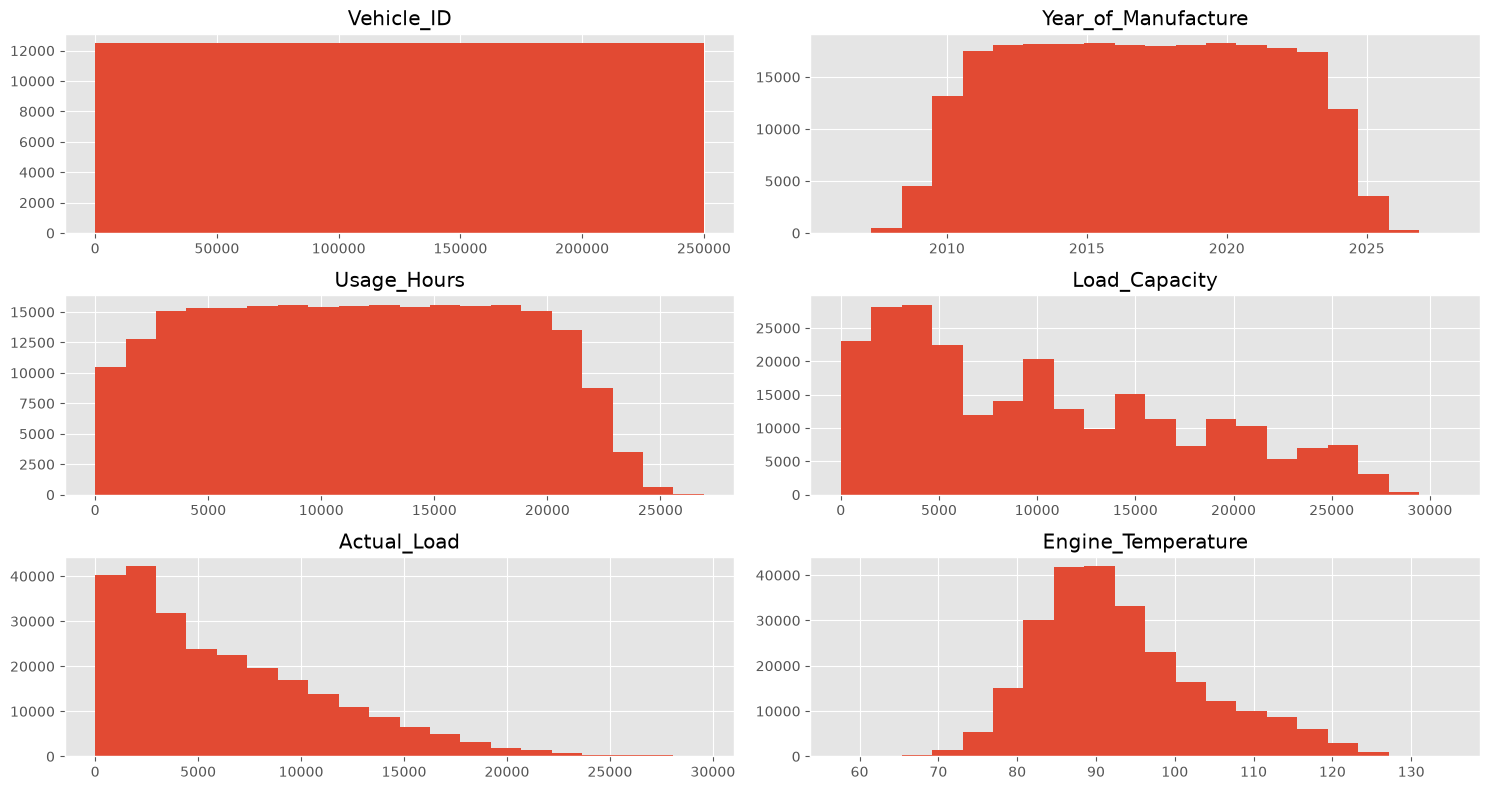

In [14]:
cols = numerical_columns[:6]

df[cols].hist(
    figsize=(15,8),
    bins=20
)

plt.tight_layout()
plt.show()

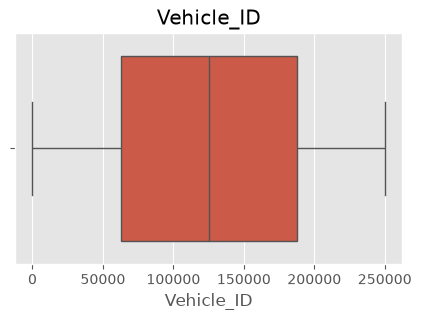

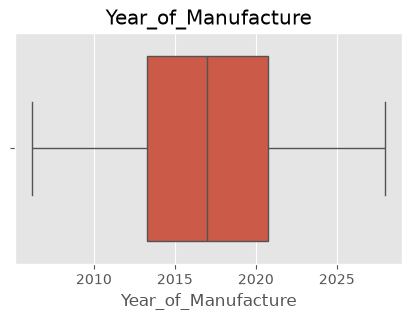

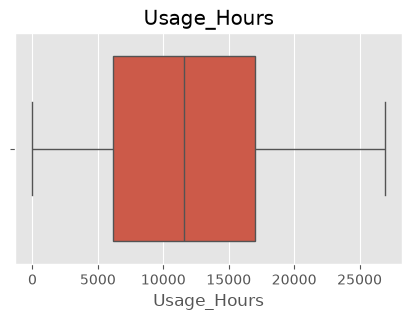

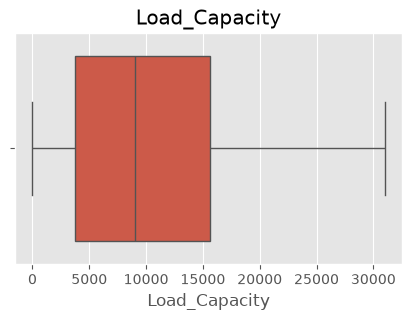

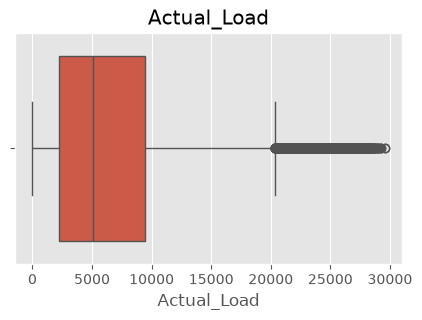

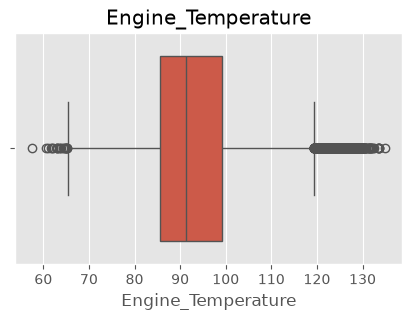

In [15]:
for col in numerical_columns[:6]:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

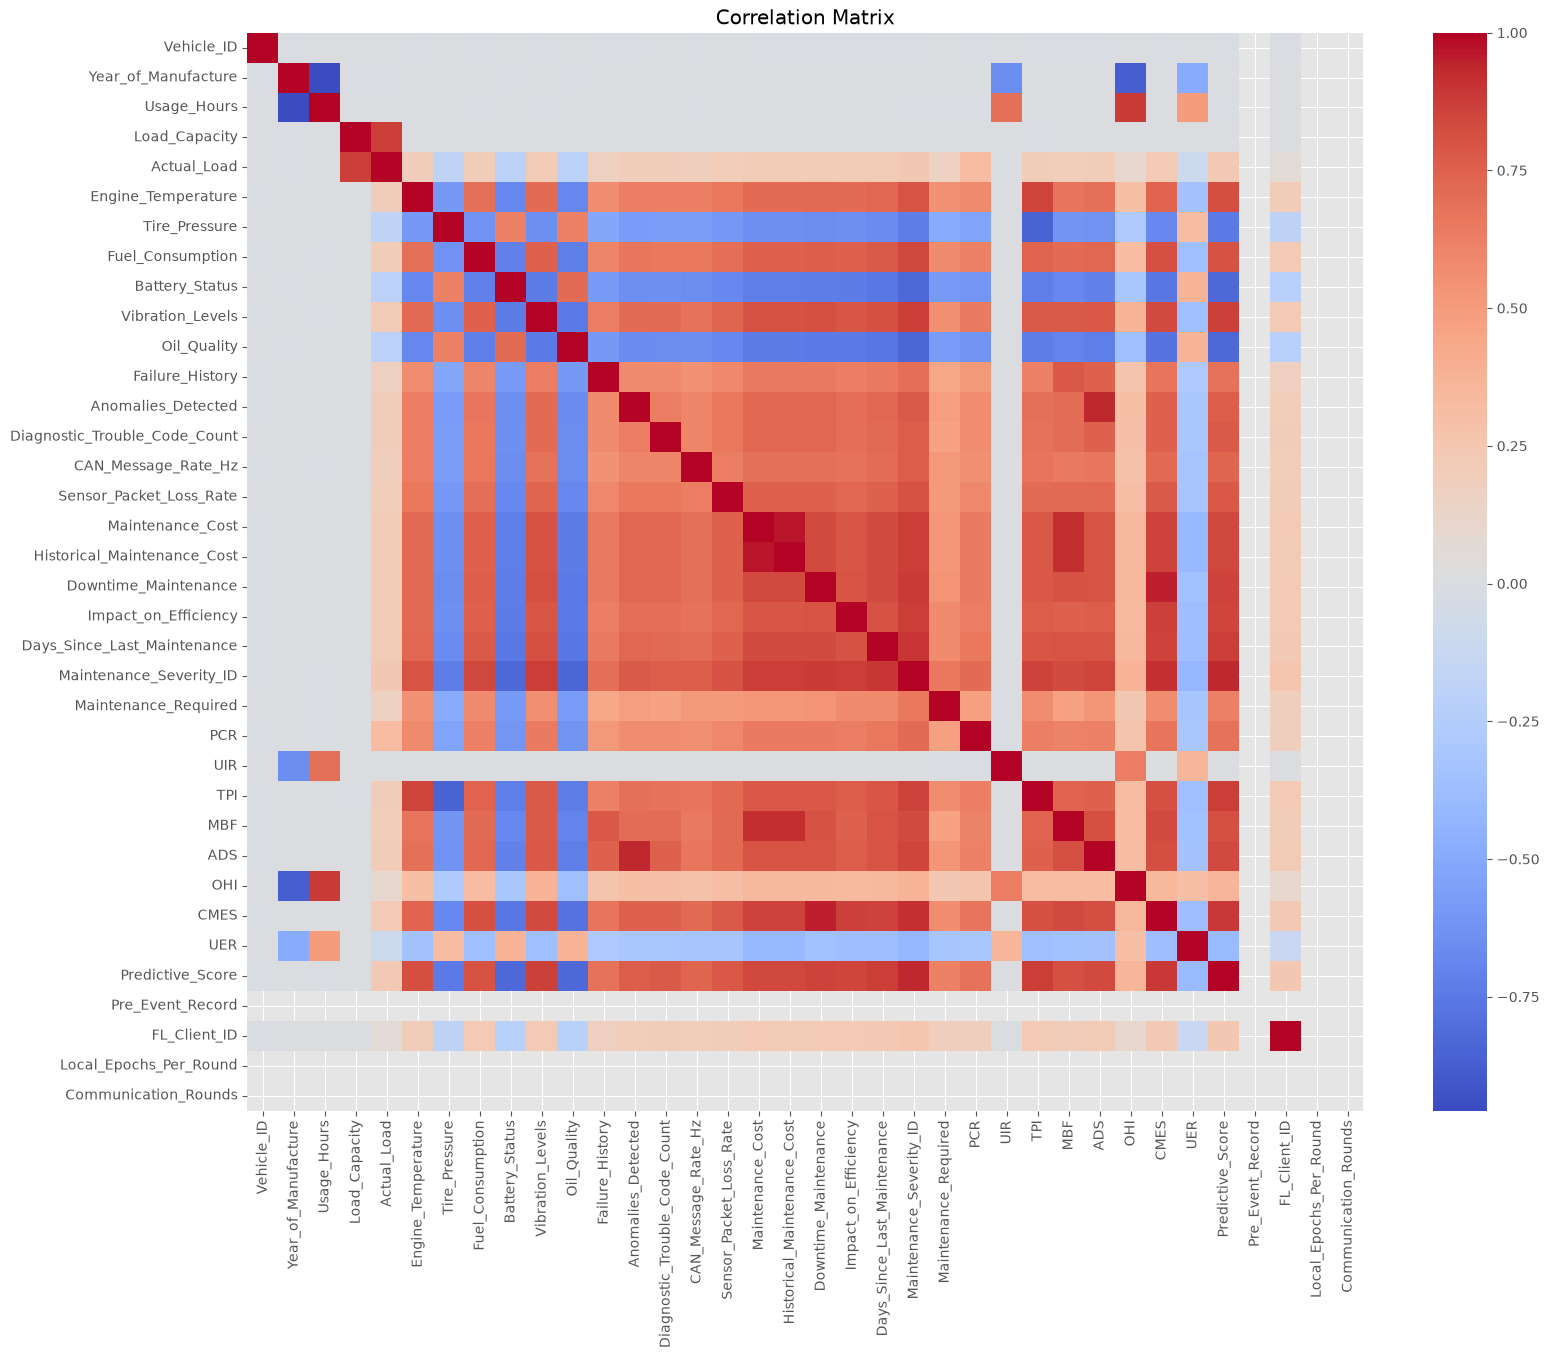

In [16]:
plt.figure(figsize=(18,14))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [17]:
for col in categorical_columns:

    print("="*40)

    print(col)

    print(df[col].unique())

    print()

Make_and_Model
<StringArray>
[     'Ford F-150', 'Chevy Silverado',         'MAN TGX', 'Mercedes Actros',
        'Volvo FH',      'Tesla Semi', 'Scania R-Series',       'Isuzu NPR']
Length: 8, dtype: str

Vehicle_Type
<StringArray>
['Refrigerated Truck',        'Light Truck',       'Medium Truck',
     'Electric Truck',        'Heavy Truck']
Length: 5, dtype: str

Route_Info
<StringArray>
[    'Highway Freight',    'Cold-Chain Route', 'Intercity Logistics',
      'Urban Delivery',   'Port-to-Warehouse']
Length: 5, dtype: str

Weather_Conditions
<StringArray>
['Humid', 'Rainy', 'Hot', 'Clear', 'Foggy', 'Cold']
Length: 6, dtype: str

Road_Conditions
<StringArray>
['Smooth', 'Rough', 'Congested', 'Moderate', 'Mountainous']
Length: 5, dtype: str

Communication_Interface
<StringArray>
['CAN/LIN', 'OBD-II/CAN', 'CAN-FD/Telematics', 'OBD-II/CAN/LIN']
Length: 4, dtype: str

Telematics_Gateway
<StringArray>
['Edge_Telematics_Box', 'Fleet_IoT_Node', 'OBD_Gateway', 'Embedded_TCU']
Length: 4, dty

In [18]:
df.describe().to_csv(
    "data/raw/descriptive_statistics.csv"
)